In [12]:
!pip install yfinance pmdarima --quiet

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf


In [13]:
def test_stationarity(timeseries):
    rolmean = timeseries.rolling(12).mean()
    rolstd = timeseries.rolling(12).std()

    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.show()

    print("Results of Dickey-Fuller Test")
    adft = adfuller(timeseries, autolag='AIC')
    output = pd.Series(adft[0:4],
        index=['Test Statistic','p-value','No. of lags used','Number of observations used'])
    for key,values in adft[4].items():
        output['critical value (%s)'%key] = values
    print(output)


In [14]:
tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]



ARIMA ANALYSIS FOR RELIANCE.NS


[*********************100%***********************]  1 of 1 completed


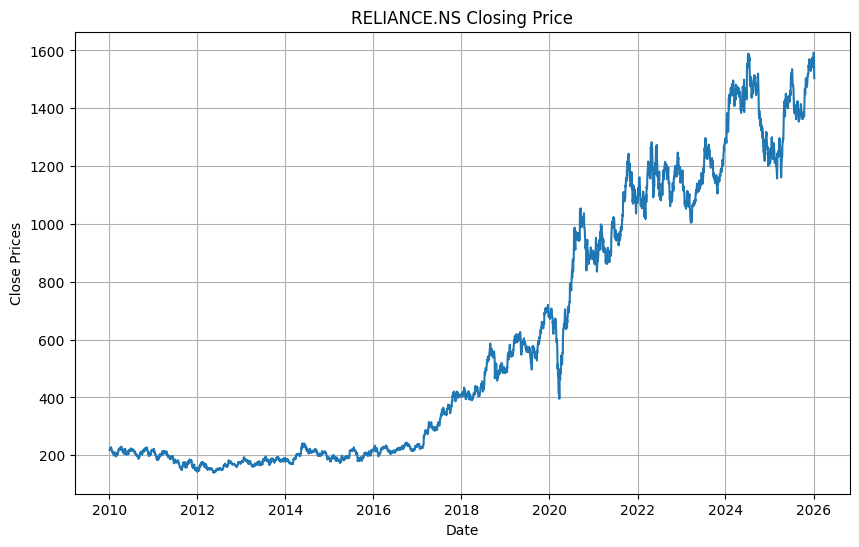

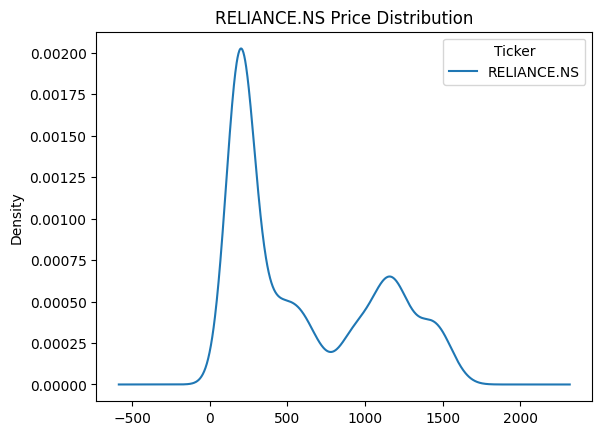

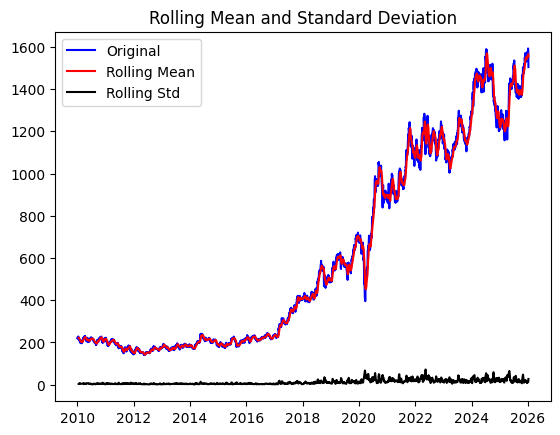

Results of Dickey-Fuller Test
Test Statistic                    0.256252
p-value                           0.975246
No. of lags used                  3.000000
Number of observations used    3952.000000
critical value (1%)              -3.432006
critical value (5%)              -2.862272
critical value (10%)             -2.567159
dtype: float64


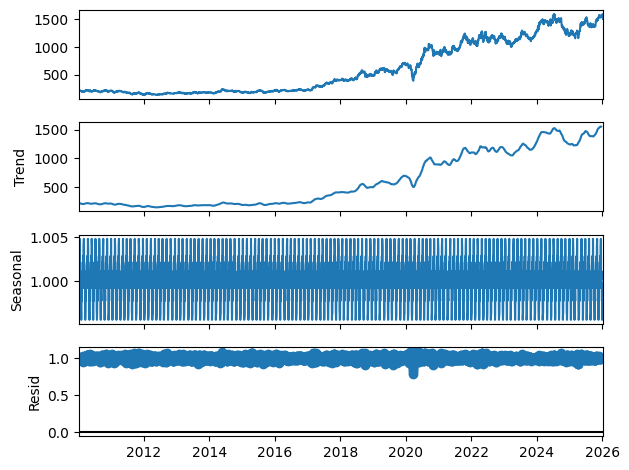

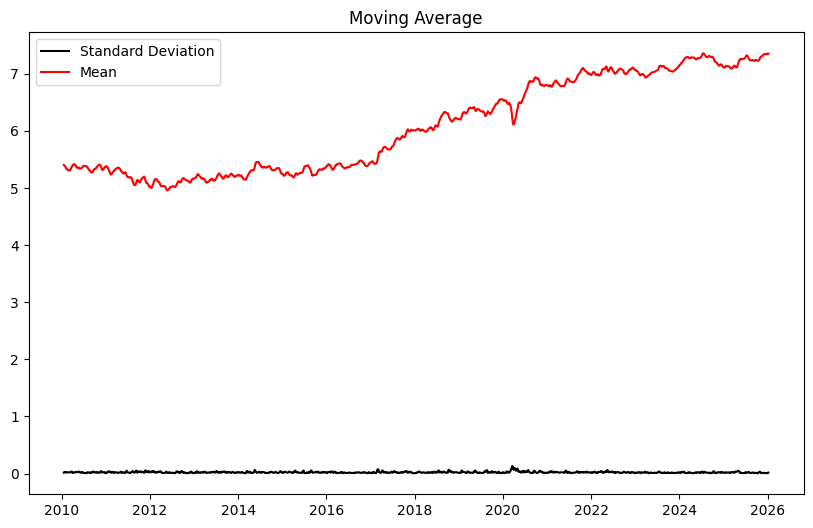

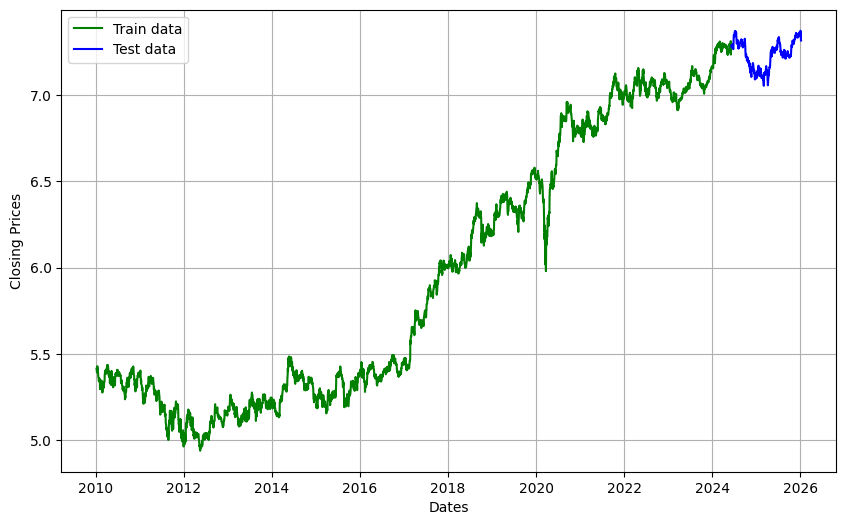

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-18724.216, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-18722.505, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-18722.494, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-18722.962, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-18720.216, Time=0.57 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.268 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3557
Model:               SARIMAX(0, 1, 0)   Log Likelihood                9364.108
Date:                Wed, 07 Jan 2026   AIC                         -18724.216
Time:                        21:52:51   BIC                         -18711.864
Sample:                             0   HQIC                        -18719.811
                               - 3557                             

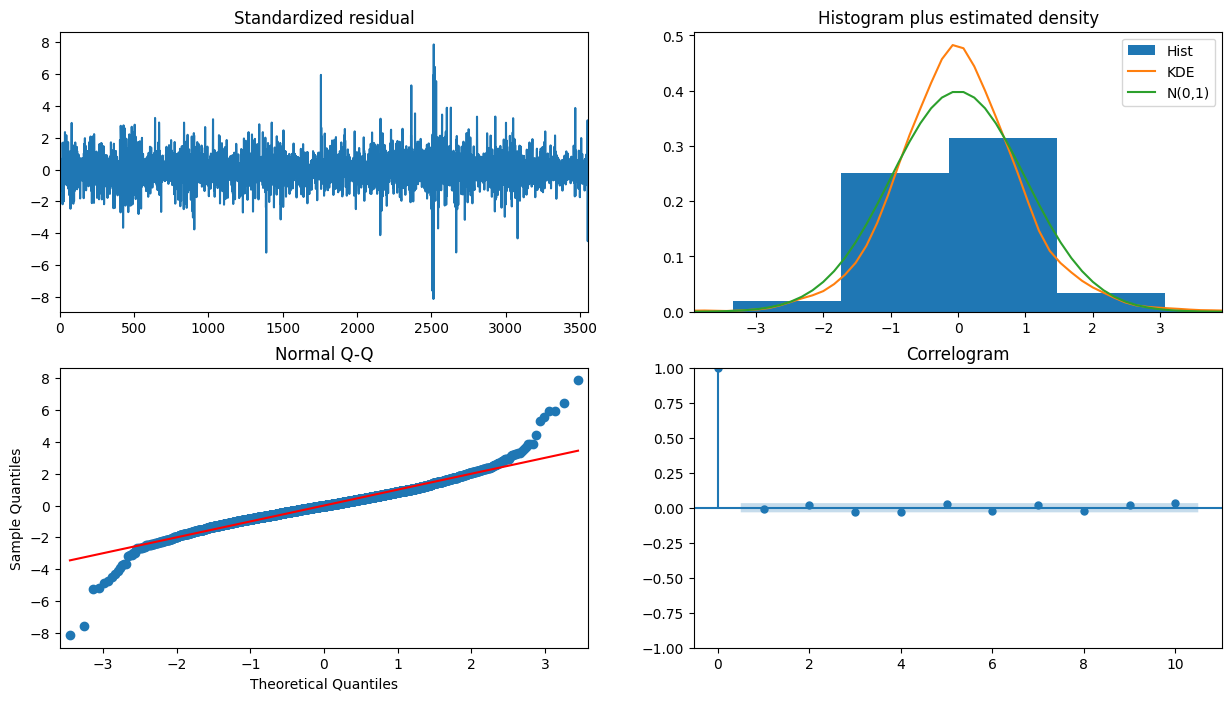

                               SARIMAX Results                                
Dep. Variable:            RELIANCE.NS   No. Observations:                 3557
Model:                 ARIMA(0, 1, 0)   Log Likelihood                9362.481
Date:                Wed, 07 Jan 2026   AIC                         -18722.962
Time:                        21:52:51   BIC                         -18716.786
Sample:                             0   HQIC                        -18720.759
                               - 3557                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0003   3.57e-06     84.583      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.29   Jarque-Bera (JB):              5419.05
Prob(Q):                              0.59   Pr

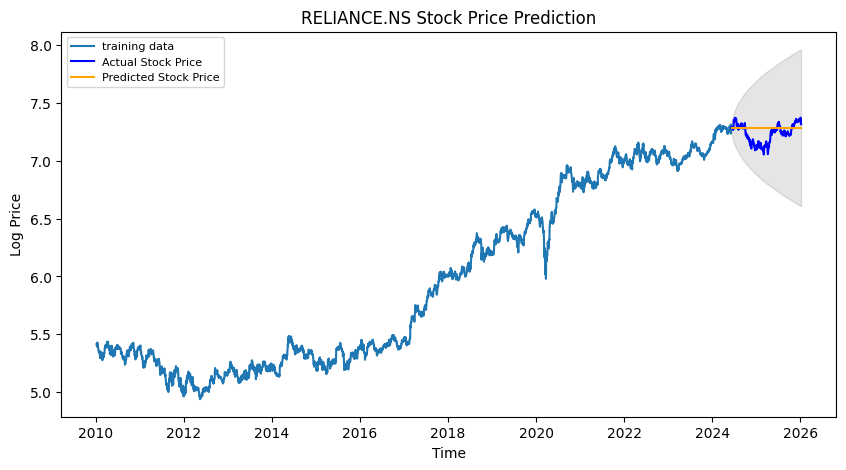

MSE : 0.008997078824947213
MAE : 0.07411773797043252
RMSE: 0.09485293261121247
MAPE: nan

ARIMA ANALYSIS FOR TCS.NS


[*********************100%***********************]  1 of 1 completed


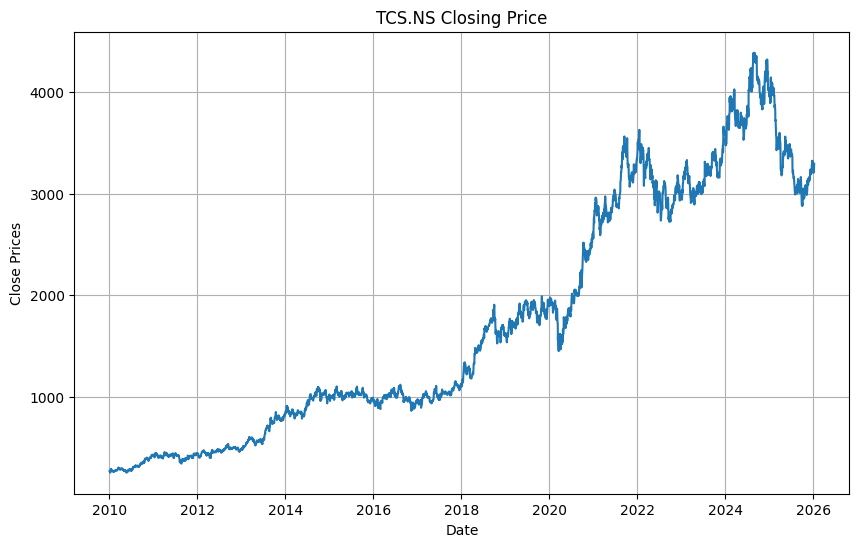

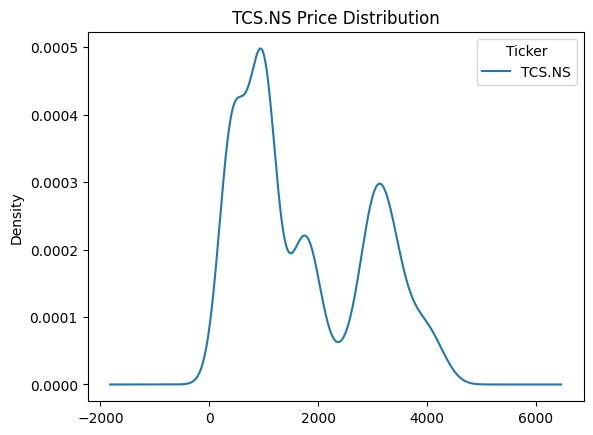

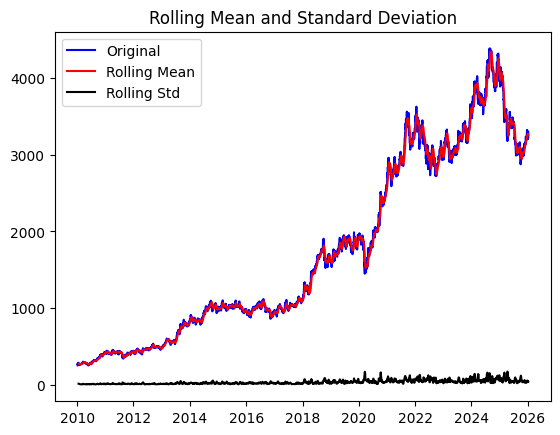

Results of Dickey-Fuller Test
Test Statistic                   -0.563563
p-value                           0.879005
No. of lags used                 31.000000
Number of observations used    3924.000000
critical value (1%)              -3.432018
critical value (5%)              -2.862277
critical value (10%)             -2.567162
dtype: float64


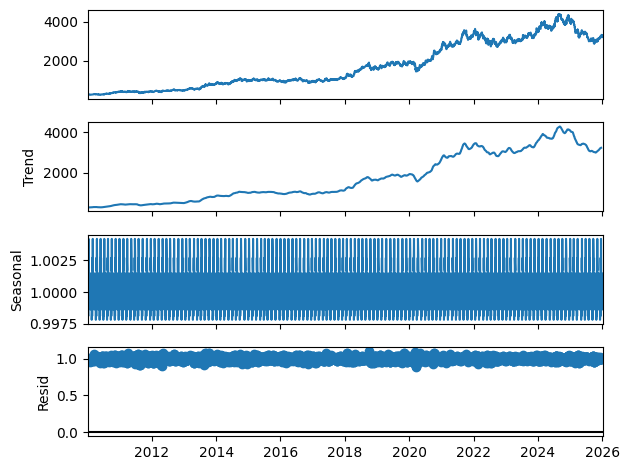

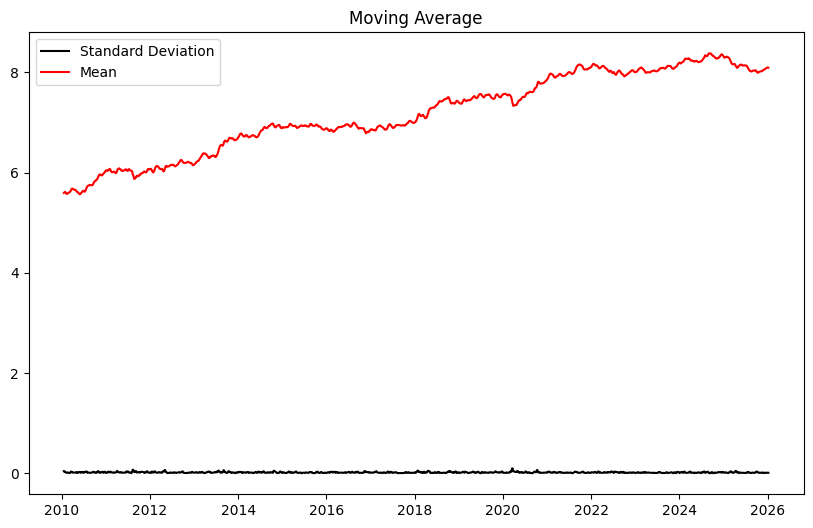

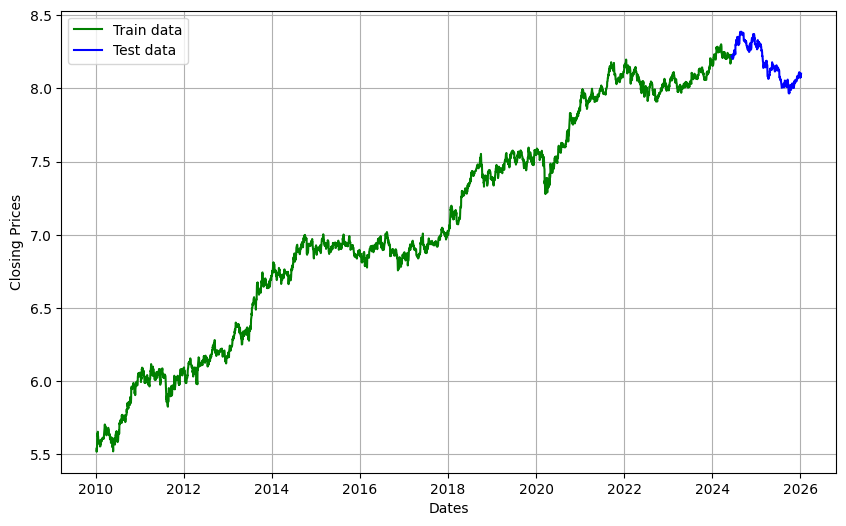

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-19457.678, Time=0.23 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-19455.794, Time=0.30 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-19455.797, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-19451.412, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-19453.678, Time=0.57 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.336 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3557
Model:               SARIMAX(0, 1, 0)   Log Likelihood                9730.839
Date:                Wed, 07 Jan 2026   AIC                         -19457.678
Time:                        21:52:54   BIC                         -19445.325
Sample:                             0   HQIC                        -19453.273
                               - 3557                             

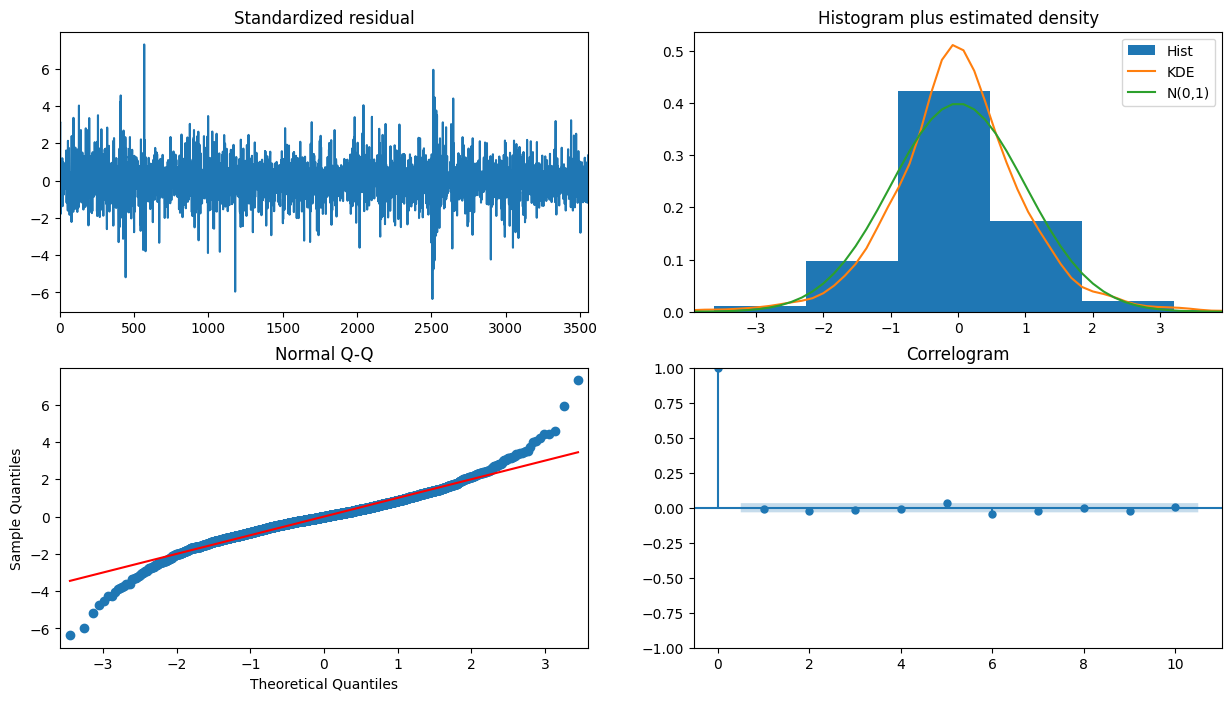

                               SARIMAX Results                                
Dep. Variable:                 TCS.NS   No. Observations:                 3557
Model:                 ARIMA(0, 1, 0)   Log Likelihood                9726.706
Date:                Wed, 07 Jan 2026   AIC                         -19451.412
Time:                        21:52:55   BIC                         -19445.236
Sample:                             0   HQIC                        -19449.210
                               - 3557                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0002   3.46e-06     71.286      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):              2058.33
Prob(Q):                              0.73   Pr

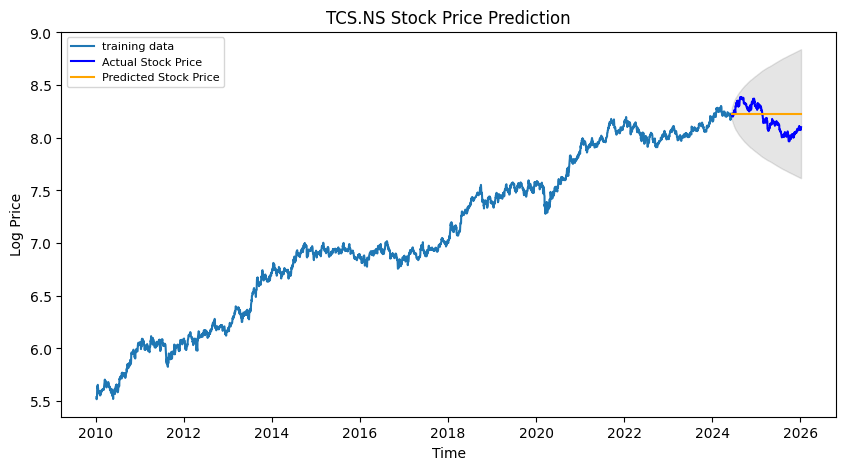

MSE : 0.017266122320523308
MAE : 0.11621426128616218
RMSE: 0.13140061765655178
MAPE: nan

ARIMA ANALYSIS FOR INFY.NS


[*********************100%***********************]  1 of 1 completed


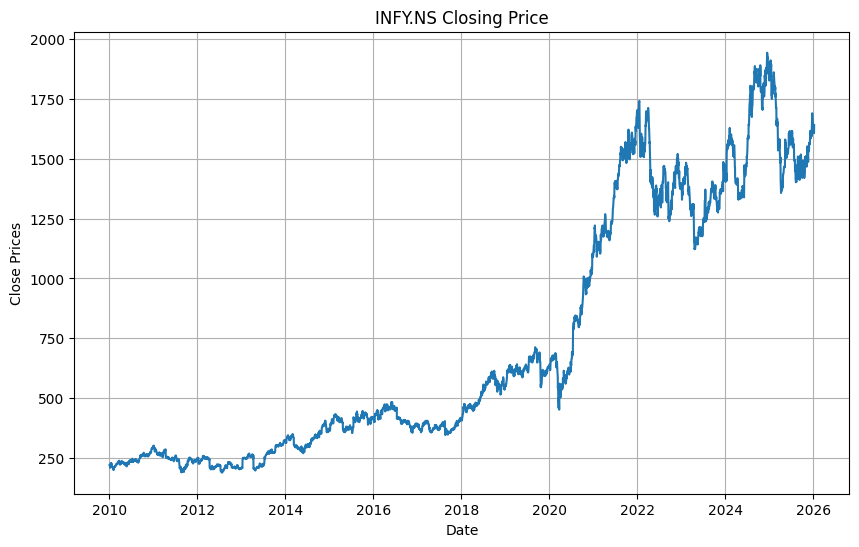

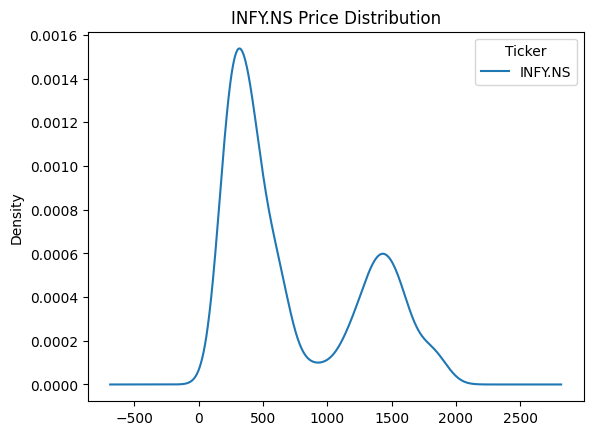

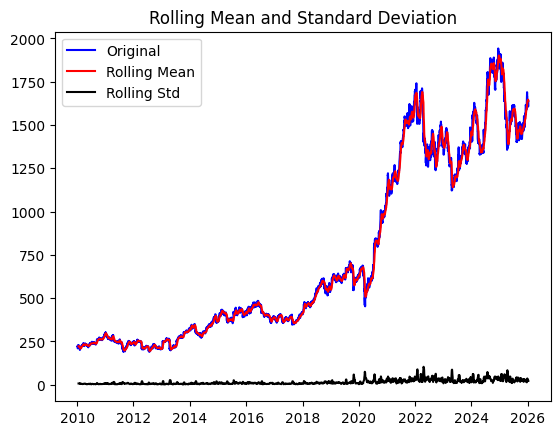

Results of Dickey-Fuller Test
Test Statistic                   -0.290335
p-value                           0.926862
No. of lags used                 31.000000
Number of observations used    3924.000000
critical value (1%)              -3.432018
critical value (5%)              -2.862277
critical value (10%)             -2.567162
dtype: float64


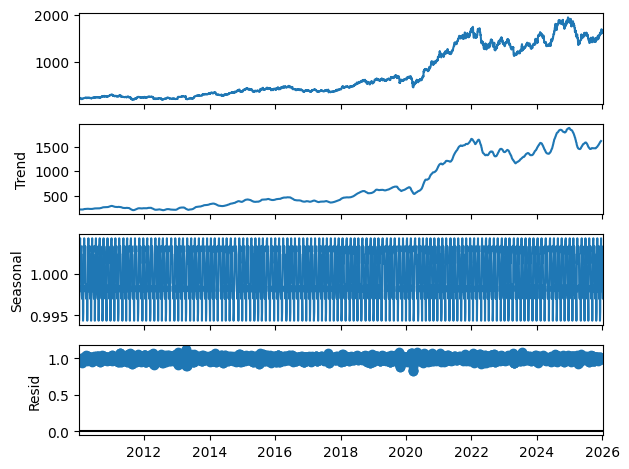

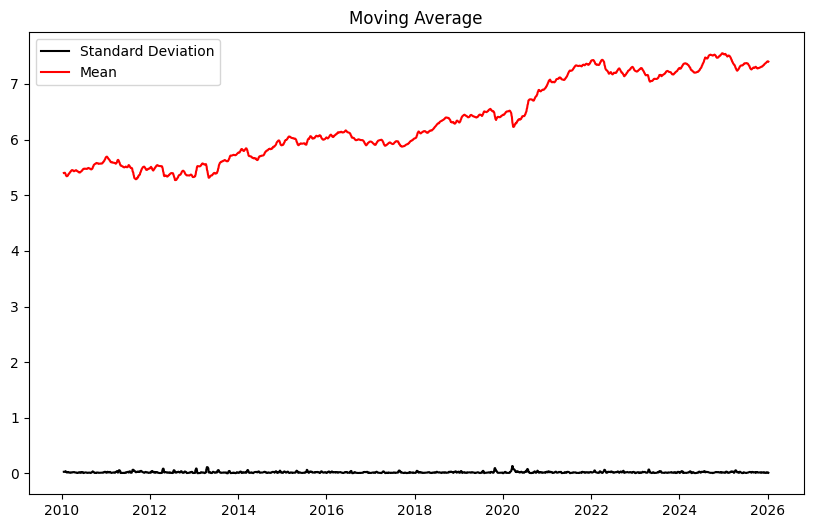

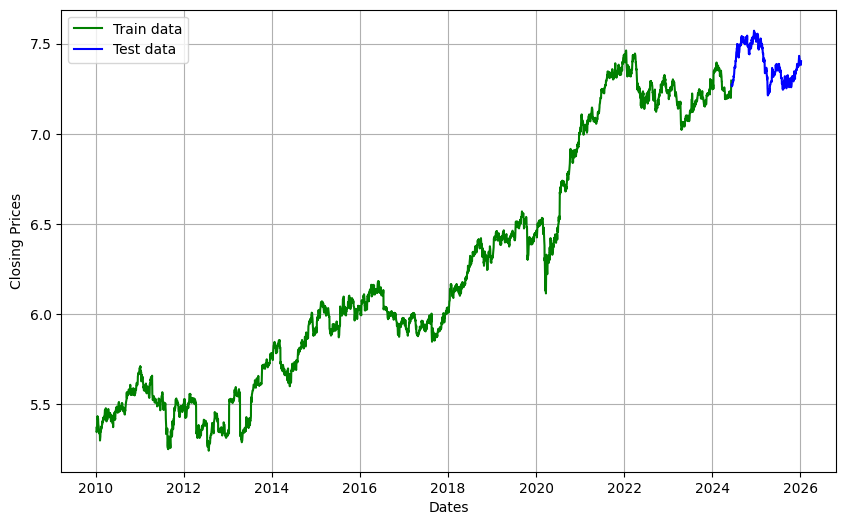

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-18741.756, Time=0.32 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-18739.756, Time=0.36 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-18739.756, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-18740.290, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-18737.778, Time=0.20 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.333 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3557
Model:               SARIMAX(0, 1, 0)   Log Likelihood                9372.878
Date:                Wed, 07 Jan 2026   AIC                         -18741.756
Time:                        21:52:58   BIC                         -18729.403
Sample:                             0   HQIC                        -18737.351
                               - 3557                             

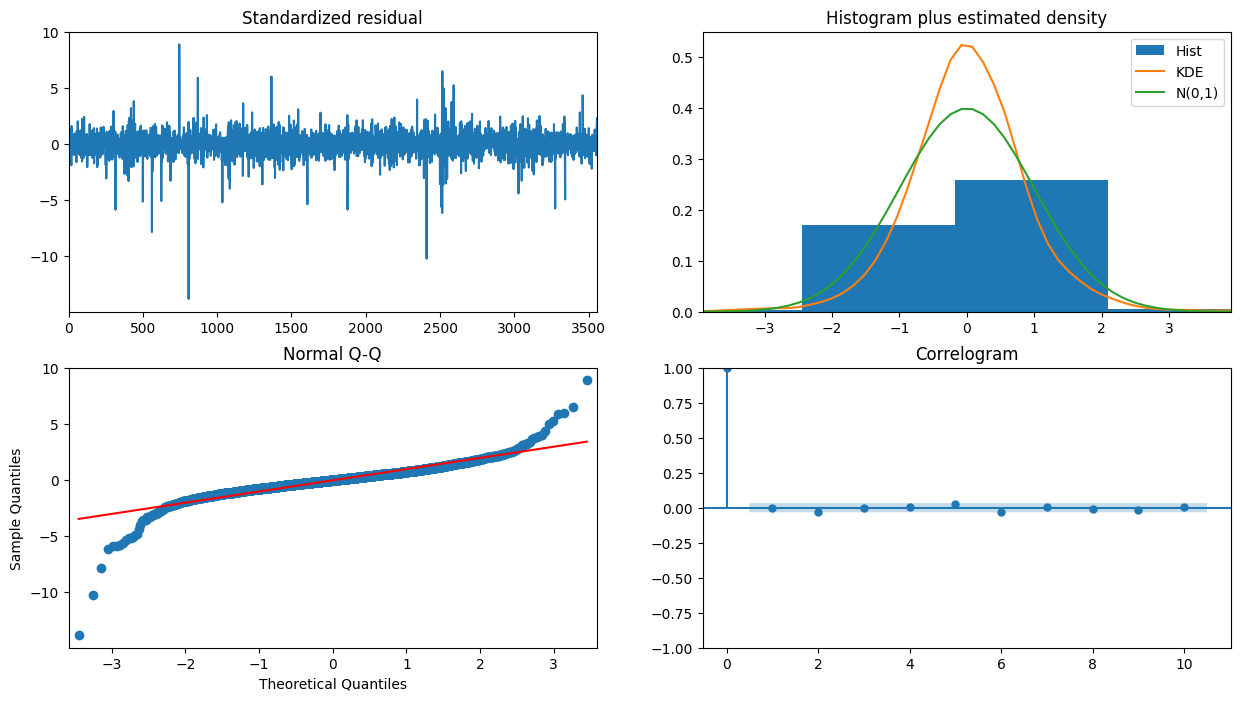

                               SARIMAX Results                                
Dep. Variable:                INFY.NS   No. Observations:                 3557
Model:                 ARIMA(0, 1, 0)   Log Likelihood                9371.145
Date:                Wed, 07 Jan 2026   AIC                         -18740.290
Time:                        21:52:58   BIC                         -18734.114
Sample:                             0   HQIC                        -18738.088
                               - 3557                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0003   2.15e-06    140.259      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             61849.03
Prob(Q):                              0.98   Pr

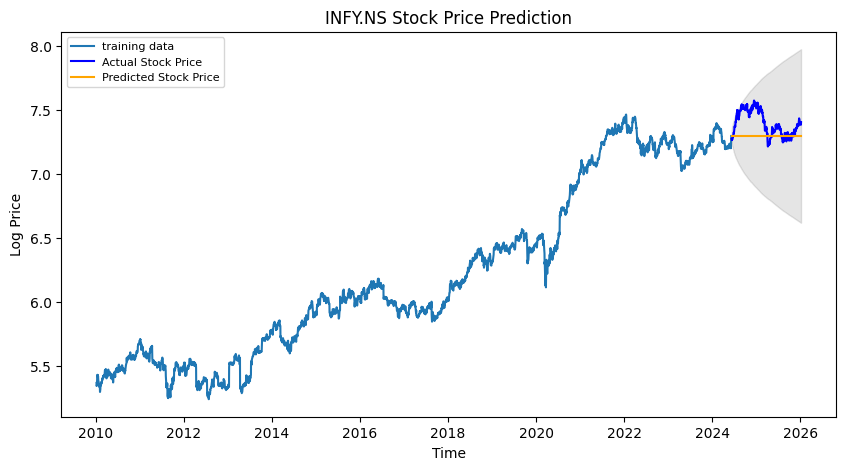

MSE : 0.01964133407459036
MAE : 0.11095853368698914
RMSE: 0.14014754394776371
MAPE: nan


In [20]:
for ticker in tickers:

    print("\n" + "="*60)
    print(f"ARIMA ANALYSIS FOR {ticker}")
    print("="*60)

    # -----------------------------
    # Load Data (yfinance instead of CSV)
    # -----------------------------
    stock_data = yf.download(ticker, start="2010-01-01")
    stock_data = stock_data[['Close']]
    stock_data.fillna(0, inplace=True)
    
    

    # -----------------------------
    # Plot Close Price
    # -----------------------------
    plt.figure(figsize=(10,6))
    plt.grid(True)
    plt.xlabel('Date')
    plt.ylabel('Close Prices')
    plt.plot(stock_data['Close'])
    plt.title(f'{ticker} Closing Price')
    plt.show()

    # -----------------------------
    # Distribution
    # -----------------------------
    df_close = stock_data['Close']
    df_close.plot(kind='kde', title=f"{ticker} Price Distribution")
    plt.show()

    # -----------------------------
    # Stationarity Test
    # -----------------------------
    test_stationarity(df_close)

    # -----------------------------
    # Seasonal Decomposition
    # -----------------------------
    result = seasonal_decompose(df_close, model='multiplicative', period=30)
    result.plot()
    plt.show()

    # -----------------------------
    # Log Transform + Moving Average
    # -----------------------------
    df_log = np.log(df_close)

    moving_avg = df_log.rolling(12).mean()
    std_dev = df_log.rolling(12).std()

    plt.figure(figsize=(10,6))
    plt.plot(std_dev, color="black", label="Standard Deviation")
    plt.plot(moving_avg, color="red", label="Mean")
    plt.legend()
    plt.title("Moving Average")
    plt.show()

    # -----------------------------
    # Train-Test Split
    # -----------------------------
    train_data = df_log[3:int(len(df_log)*0.9)]
    test_data = df_log[int(len(df_log)*0.9):]

    plt.figure(figsize=(10,6))
    plt.grid(True)
    plt.xlabel('Dates')
    plt.ylabel('Closing Prices')
    plt.plot(train_data, 'green', label='Train data')
    plt.plot(test_data, 'blue', label='Test data')
    plt.legend()
    plt.show()

    # -----------------------------
    # Auto ARIMA
    # -----------------------------
    model_autoARIMA = auto_arima(
        train_data,
        start_p=0, start_q=0,
        test='adf',
        max_p=3, max_q=3,
        m=1,
        d=None,
        seasonal=False,
        start_P=0,
        D=0,
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )

    print(model_autoARIMA.summary())
    model_autoARIMA.plot_diagnostics(figsize=(15,8))
    plt.show()

    # -----------------------------
    # Build ARIMA Model
    # -----------------------------
    model = ARIMA(train_data, order=model_autoARIMA.order)
    fitted = model.fit()
    print(fitted.summary())

    # -----------------------------
    # Forecast (MODERN API, NO LOGIC CHANGE)
    # -----------------------------
    forecast_obj = fitted.get_forecast(steps=len(test_data))
    fc = forecast_obj.predicted_mean
    conf = forecast_obj.conf_int()

    fc.index = test_data.index
    conf.index = test_data.index

    # -----------------------------
    # Plot Forecast
    # -----------------------------
    plt.figure(figsize=(10,5), dpi=100)
    plt.plot(train_data, label='training data')
    plt.plot(test_data, color='blue', label='Actual Stock Price')
    plt.plot(fc, color='orange', label='Predicted Stock Price')
    plt.fill_between(
        conf.index,
        conf.iloc[:,0],
        conf.iloc[:,1],
        color='k',
        alpha=.10
    )
    plt.title(f'{ticker} Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('Log Price')
    plt.legend(loc='upper left', fontsize=8)
    plt.show()

    # -----------------------------
    # Performance Metrics (UNCHANGED)
    # -----------------------------
    mse = mean_squared_error(test_data, fc)
    mae = mean_absolute_error(test_data, fc)
    rmse = math.sqrt(mse)
    mape = np.mean(np.abs(fc - test_data)/np.abs(test_data))

    print("MSE :", mse)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)


In [6]:
results_df = pd.DataFrame(results).T
results_df


,RMSE,MAE,MAPE
RELIANCE.NS,0.094853,0.074118,NaN
TCS.NS,0.131401,0.116214,NaN
INFY.NS,0.140148,0.110959,NaN
